# Spherical Anomaly Signature

In [16]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# ── locate solver root relative to this notebook ────────────────────────────────
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()

# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey
from elfe3d_gpr.inputs.anomalies import SphereAnomaly

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, CSVFieldLoader, GPRDataset
from elfe3d_gpr.outputs.postprocess import field_error, field_simple_error, error_stats
from elfe3d_gpr.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot, 
                          ReceiverLineSimpleErrorPlot, SimpleErrorHistogramPlot)

# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = '',
    use_wsl    = True,   # False if running the solver directly inside WSL
)

print('Solver root:', MASTER_PATH)
print('Executable:', paths.exec_path())


Solver root: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR
Executable: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


## Half-Space Solution

In [17]:
output_dir = Path(paths.master_dir) / Path("out_homogeneous_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_hs.r.min():.3f} - {ef_hs.r.max():.3f} m   ({len(ef_hs.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Half-Space Solution

In [18]:
output_dir = Path(paths.master_dir) / Path("out_anomaly_sphere_hs")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere_hs\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [19]:
# Difference: Sphere in Half-Space - Half-Space (Sphere Signature)
diff_hs_amp = field_simple_error(ef_hs, ef_s_hs, 0)
diff_hs_phase = field_simple_error(ef_hs, ef_s_hs, 1)
diff_hs_real = field_simple_error(ef_hs, ef_s_hs, 2)
diff_hs_imag = field_simple_error(ef_hs, ef_s_hs, 3)

print("Half-Space Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_hs_amp):.4e}, max={np.nanmax(diff_hs_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_hs_phase):.4e}, max={np.nanmax(diff_hs_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_hs_real):.4e}, max={np.nanmax(diff_hs_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_hs_imag):.4e}, max={np.nanmax(diff_hs_imag):.4e}")

Half-Space Sphere Signature:
  Amplitude diff: mean=1.0702e+01, max=1.6325e+02
  Phase diff:     mean=-9.6802e-03, max=1.9181e-03
  Real diff:      mean=3.9731e+00, max=7.8832e+00
  Imag diff:      mean=9.4001e+00, max=1.6317e+02


## Two-Layered Earth Solution

In [20]:
output_dir = Path(paths.master_dir) / Path("out_two_layered_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_tl.r.min():.3f} - {ef_tl.r.max():.3f} m   ({len(ef_tl.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_two_layered_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Two-Layered Earth Solution

In [21]:
output_dir = Path(paths.master_dir) / Path("out_anomaly_sphere")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_tl.r.min():.3f} - {ef_s_tl.r.max():.3f} m   ({len(ef_s_tl.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [22]:
# Difference: Sphere in Two-Layered - Two-Layered (Sphere Signature)
diff_tl_amp = field_simple_error(ef_tl, ef_s_tl, 0)
diff_tl_phase = field_simple_error(ef_tl, ef_s_tl, 1)
diff_tl_real = field_simple_error(ef_tl, ef_s_tl, 2)
diff_tl_imag = field_simple_error(ef_tl, ef_s_tl, 3)

print("Two-Layered Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_tl_amp):.4e}, max={np.nanmax(diff_tl_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_tl_phase):.4e}, max={np.nanmax(diff_tl_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_tl_real):.4e}, max={np.nanmax(diff_tl_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_tl_imag):.4e}, max={np.nanmax(diff_tl_imag):.4e}")

Two-Layered Sphere Signature:
  Amplitude diff: mean=1.0311e+01, max=7.3625e+01
  Phase diff:     mean=-1.0809e-01, max=1.1384e-01
  Real diff:      mean=3.9888e+00, max=5.4353e+00
  Imag diff:      mean=9.3701e+00, max=7.3534e+01


## $miepython$ Sphere Solution

In [23]:
# Load miepython sphere solution (analytical scattering from sphere in half-space)
MIE_DATA_DIR = Path(paths.master_dir).parent / Path("data\data_miepython")

mie = CSVFieldLoader(
    filepath=os.path.join(MIE_DATA_DIR, 'endfire_electric_field.csv'),
    label='miepython (Analytical Sphere)',
    distance_col='Distance (m)',
    orientation='Endfire'
).ex()

print(f'miepython r : {mie.r.min():.3f} - {mie.r.max():.3f} m   ({len(mie.r)} receivers)')
print(f'elfe3D sphere (hs) r: {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')

miepython r : 0.100 - 1.000 m   (48 receivers)
elfe3D sphere (hs) r: 0.100 - 1.000 m   (48 receivers)


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Knight\AppData\Local\Temp\ipykernel_37452\885325853.py:2: SyntaxWarning: invalid escape sequence '\d'
  MIE_DATA_DIR = Path(paths.master_dir).parent / Path("data\data_miepython")


## Comparison

In [24]:
# Normalize all datasets to compare shapes (scale to max amplitude = 1)
def normalize_dataset(ds: GPRDataset, suffix: str = "(norm)") -> GPRDataset:
    """Normalize amplitude, real, imag to same max; phase unchanged."""
    max_val = max(np.abs(ds.amp).max(), np.abs(ds.real).max(), np.abs(ds.imag).max())
    if max_val == 0:
        return ds
    return GPRDataset(
        amp=ds.amp / max_val,
        phase=ds.phase,
        real=ds.real / max_val,
        imag=ds.imag / max_val,
        orientation=ds.orientation,
        r=ds.r,
        label=f"{ds.label} {suffix}"
    )

# Normalize all three datasets
mie_real = mie.real
mie_real *= -1
mie_phase = np.arctan2(mie.imag, mie_real)
mie = GPRDataset(
    amp=mie.amp,
    phase=mie_phase,
    real=mie_real,
    imag=mie.imag,
    orientation=mie.orientation,
    r=mie.r,
    label=mie.label
)
# mie_norm = normalize_dataset(mie)
# ef_s_hs_norm = normalize_dataset(ef_s_hs)
# ef_hs_norm = normalize_dataset(ef_hs)
mie_norm = mie
ef_s_hs_norm = ef_s_hs
ef_hs_norm = ef_hs

print("Normalized datasets:")
print(f"  miepython max amp: {mie_norm.amp.max():.4f}")
print(f"  elfe3D sphere (hs) max amp: {ef_s_hs_norm.amp.max():.4f}")
print(f"  elfe3D half-space max amp: {ef_hs_norm.amp.max():.4f}")

Normalized datasets:
  miepython max amp: 1215629571509.5906
  elfe3D sphere (hs) max amp: 9837.8190
  elfe3D half-space max amp: 9674.5662


## Overlapped Subplots

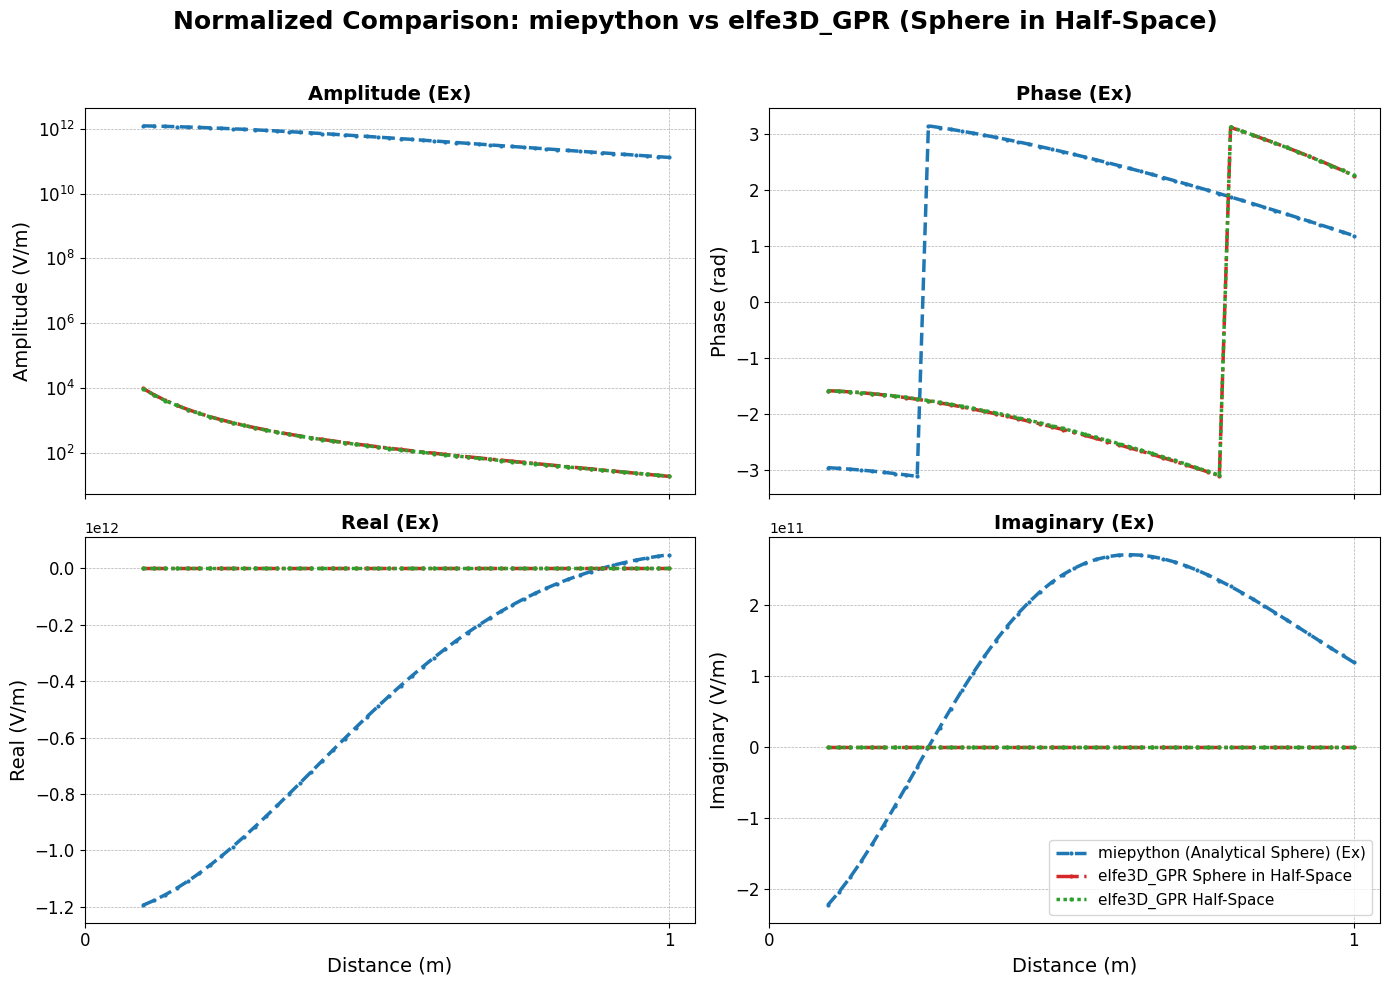

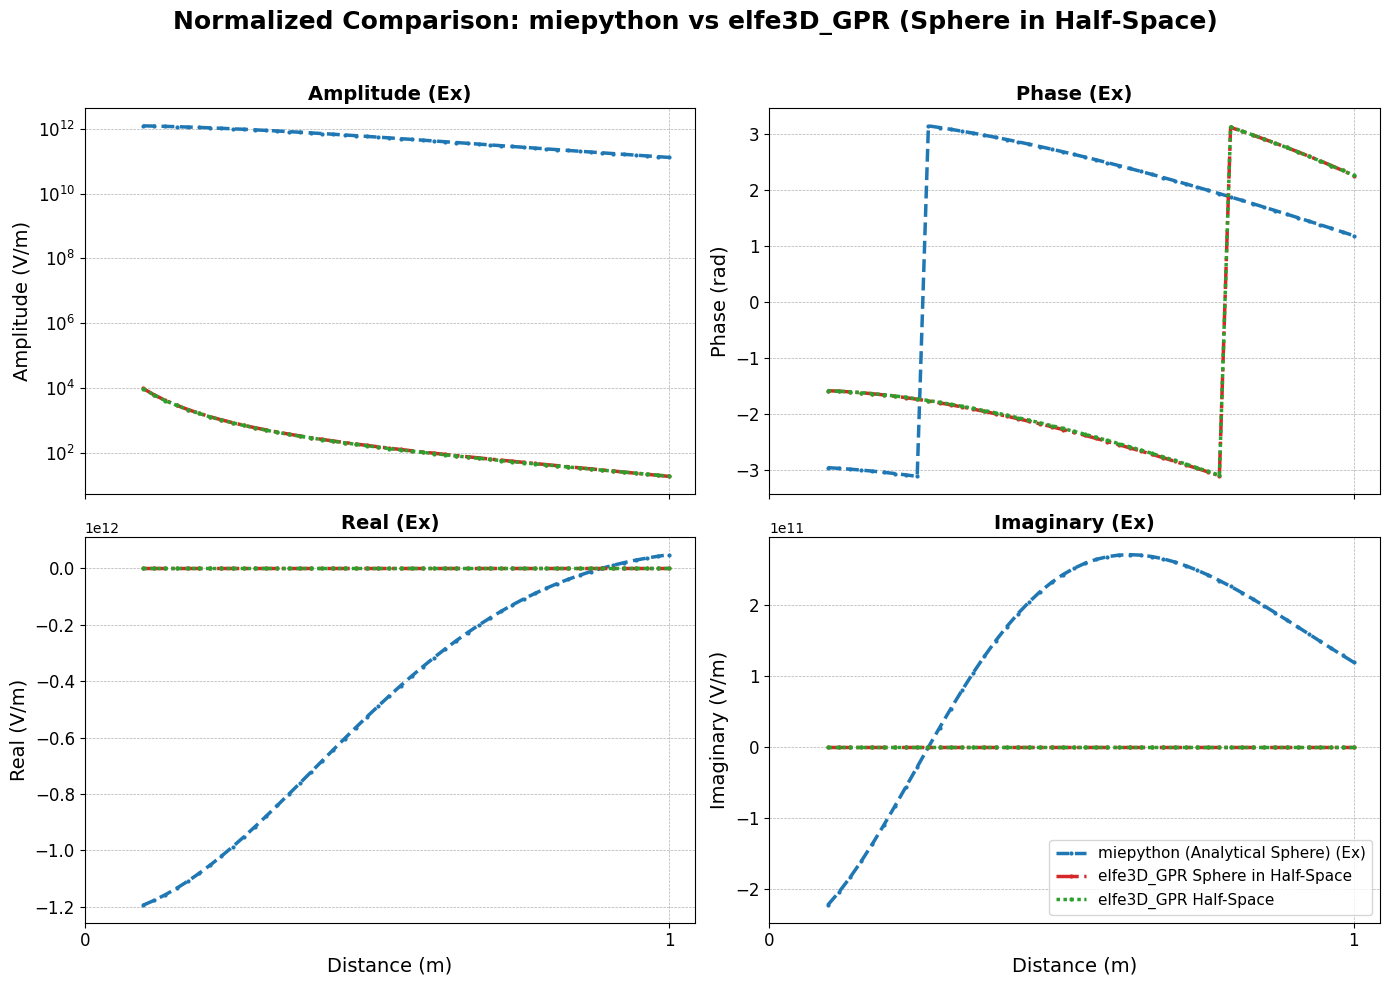

In [25]:
# Plot normalized comparison: miepython vs elfe3D sphere vs half-space background
ReceiverLinePlot(
    datasets=[mie_norm, ef_s_hs_norm, ef_hs_norm],
    base_lw=2.5,
    font={"suptitle": 18, "label": 14, "tick": 12, "legend": 11},
    figsize=(14, 10)
).plot(suptitle="Normalized Comparison: miepython vs elfe3D_GPR (Sphere in Half-Space)")

## Difference: elfe3D sphere vs miepython

In [26]:
# Compute error between elfe3D sphere solution and miepython analytical solution
# Note: may need to interpolate if receiver grids differ
print("elfe3D_GPR Sphere vs miepython (Analytical):")
print(f"  miepython r range: {mie.r.min():.3f} - {mie.r.max():.3f} m")
print(f"  elfe3D sphere r range: {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m")

# Use field_simple_error to compute absolute difference
diff_mie_amp = field_simple_error(mie, ef_s_hs, 0)
diff_mie_phase = field_simple_error(mie, ef_s_hs, 1)
diff_mie_real = field_simple_error(mie, ef_s_hs, 2)
diff_mie_imag = field_simple_error(mie, ef_s_hs, 3)

print(f"\n  Amplitude diff: mean={np.nanmean(diff_mie_amp):.4e}, max={np.nanmax(diff_mie_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_mie_phase):.4e}, max={np.nanmax(diff_mie_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_mie_real):.4e}, max={np.nanmax(diff_mie_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_mie_imag):.4e}, max={np.nanmax(diff_mie_imag):.4e}")

elfe3D_GPR Sphere vs miepython (Analytical):
  miepython r range: 0.100 - 1.000 m
  elfe3D sphere r range: 0.100 - 1.000 m

  Amplitude diff: mean=5.6220e+11, max=1.2156e+12
  Phase diff:     mean=-2.2413e+00, max=1.3810e+00
  Real diff:      mean=4.8399e+11, max=1.1951e+12
  Imag diff:      mean=1.8156e+11, max=2.7156e+11


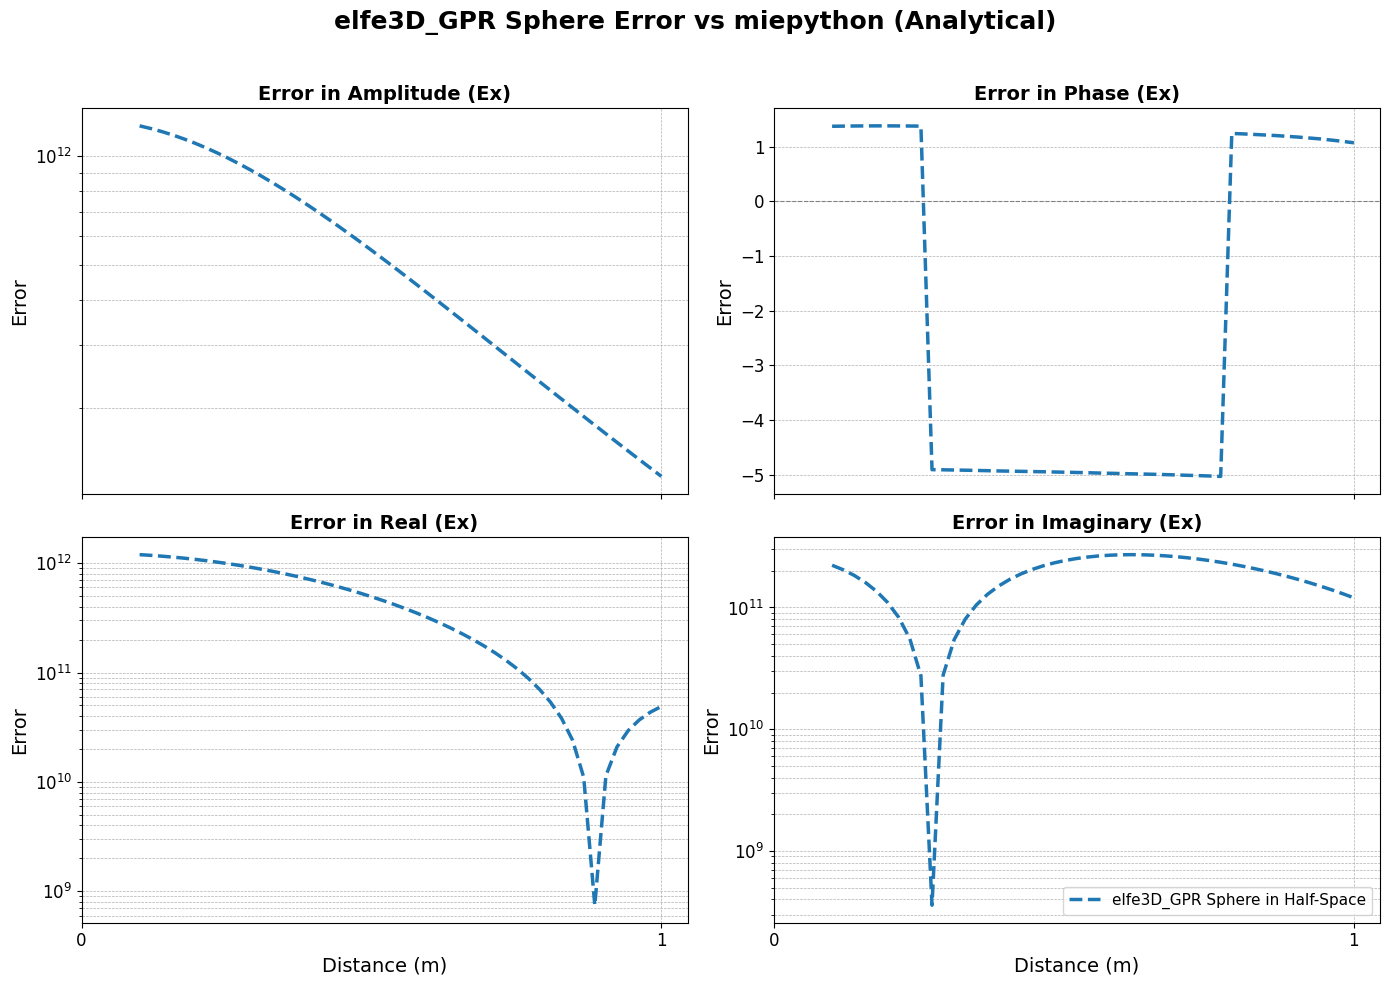

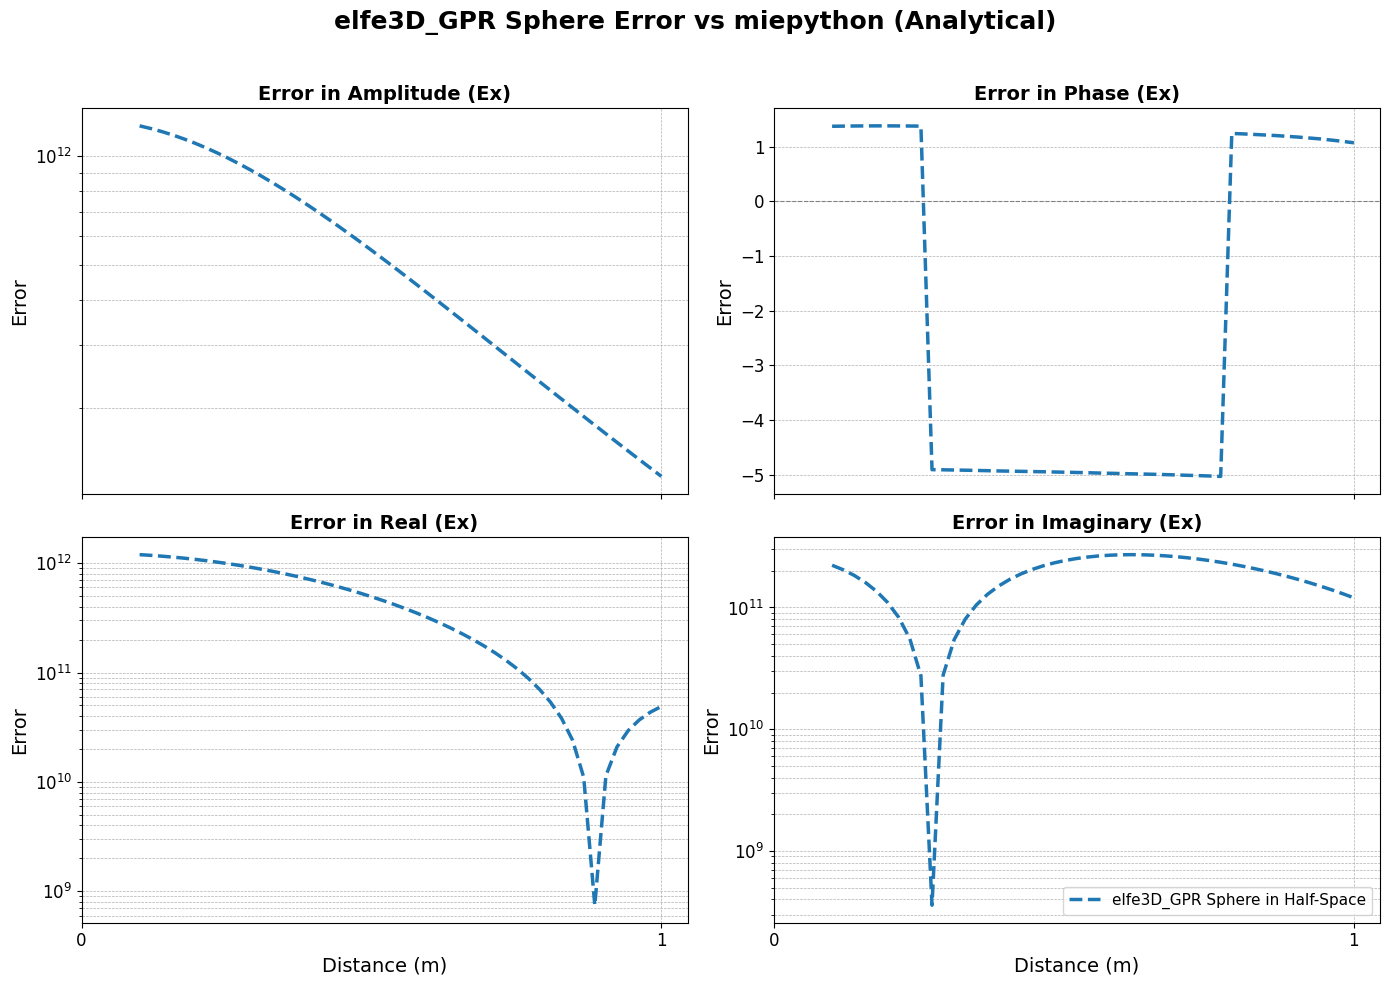

In [27]:
# Plot error: elfe3D sphere vs miepython
ReceiverLineSimpleErrorPlot(
    datasets=[ef_s_hs],
    reference=mie,
    base_lw=2.5,
    font={"suptitle": 18, "label": 14, "tick": 12, "legend": 11},
    figsize=(14, 10)
).plot(suptitle="elfe3D_GPR Sphere Error vs miepython (Analytical)")